In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)

# Plot settings
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
customers = pd.read_csv("../data/raw/customers.csv")
restaurants = pd.read_csv("../data/raw/restaurants.csv")
orders = pd.read_csv("../data/raw/orders.csv")
deliveries = pd.read_csv("../data/raw/deliveries.csv")
drivers = pd.read_csv("../data/raw/drivers.csv")
reviews = pd.read_csv("../data/raw/reviews.csv")
payments = pd.read_csv("../data/raw/payments.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [4]:
print("Customers   :", customers.shape)
print("Restaurants :", restaurants.shape)
print("Orders      :", orders.shape)
print("Deliveries  :", deliveries.shape)
print("Drivers     :", drivers.shape)
print("Reviews     :", reviews.shape)
print("Payments    :", payments.shape)

Customers   : (1000, 6)
Restaurants : (100, 6)
Orders      : (5000, 10)
Deliveries  : (5000, 7)
Drivers     : (500, 5)
Reviews     : (5000, 5)
Payments    : (5000, 4)


In [5]:
print("Customers missing values:")
print(customers.isnull().sum())

print("\nOrders missing values:")
print(orders.isnull().sum())

print("\nReviews missing values:")
print(reviews.isnull().sum())

print("\nDeliveries missing values:")
print(deliveries.isnull().sum())

Customers missing values:
customer_id        0
age                0
gender             0
city               0
signup_date        0
membership_type    0
dtype: int64

Orders missing values:
order_id                    0
customer_id                 0
restaurant_id               0
order_timestamp             0
order_amount                0
number_of_items             0
weather                     0
traffic_condition           0
order_status                0
preparation_time_minutes    0
dtype: int64

Reviews missing values:
review_id      0
order_id       0
customer_id    0
rating         0
review_text    0
dtype: int64

Deliveries missing values:
delivery_id                 0
order_id                    0
driver_id                   0
delivery_distance_km        0
preparation_time_minutes    0
delivery_time_minutes       0
tip_amount                  0
dtype: int64


In [6]:
orders["order_timestamp"] = pd.to_datetime(
    orders["order_timestamp"]
)

print(orders["order_timestamp"].dtype)

datetime64[us]


In [8]:
orders["is_weekend"] = (
    orders["order_timestamp"].dt.dayofweek >= 5
).astype(int)

orders["is_late_night"] = (
    orders["order_timestamp"].dt.hour.isin(
        [22, 23, 0, 1, 2, 3, 4, 5]
    )
).astype(int)

orders[
    [
        "order_timestamp",
        "is_weekend",
        "is_late_night"
    ]
].head()

,order_timestamp,is_weekend,is_late_night
0,2026-05-10 00:04:01,1,1
1,2026-04-30 05:33:18,0,1
2,2026-02-03 10:44:48,0,0
3,2026-05-17 07:27:57,1,0
4,2026-05-21 01:33:11,0,1


In [9]:
customer_features = orders.groupby(
    "customer_id"
).agg(
    total_orders=(
        "order_id",
        "count"
    ),

    average_order_value=(
        "order_amount",
        "mean"
    ),

    total_spending=(
        "order_amount",
        "sum"
    ),

    weekend_orders=(
        "is_weekend",
        "sum"
    ),

    late_night_orders=(
        "is_late_night",
        "sum"
    )
).reset_index()

customer_features.head()

,customer_id,total_orders,average_order_value,total_spending,weekend_orders,late_night_orders
0,CUST_0001,5,157.950000,789.75,2,2
1,CUST_0002,3,125.346667,376.04,1,1
2,CUST_0003,3,194.970000,584.91,0,1
3,CUST_0004,3,280.410000,841.23,1,1
4,CUST_0005,2,148.730000,297.46,0,2


In [10]:
customer_dates = orders.groupby(
    "customer_id"
).agg(
    first_order_date=(
        "order_timestamp",
        "min"
    ),

    last_order_date=(
        "order_timestamp",
        "max"
    )
).reset_index()

customer_dates.head()

,customer_id,first_order_date,last_order_date
0,CUST_0001,2026-01-06 12:39:23,2026-06-20 06:44:15
1,CUST_0002,2026-01-19 10:40:03,2026-03-30 08:00:34
2,CUST_0003,2026-01-29 23:33:57,2026-03-12 16:14:51
3,CUST_0004,2026-01-28 19:18:41,2026-06-29 00:07:21
4,CUST_0005,2026-01-19 23:51:29,2026-06-03 00:51:47


In [11]:
customer_dates["active_months"] = (
    (
        customer_dates["last_order_date"]
        - customer_dates["first_order_date"]
    ).dt.days / 30
).clip(lower=1)

customer_dates["active_months"].head()

0    5.466667
1    2.300000
2    1.366667
3    5.033333
4    4.466667
Name: active_months, dtype: float64

In [12]:
customer_features = customer_features.merge(
    customer_dates[
        [
            "customer_id",
            "active_months"
        ]
    ],
    on="customer_id",
    how="left"
)

customer_features["ordering_frequency"] = (
    customer_features["total_orders"]
    / customer_features["active_months"]
)

customer_features.head()

,customer_id,total_orders,average_order_value,total_spending,weekend_orders,late_night_orders,active_months,ordering_frequency
0,CUST_0001,5,157.950000,789.75,2,2,5.466667,0.914634
1,CUST_0002,3,125.346667,376.04,1,1,2.300000,1.304348
2,CUST_0003,3,194.970000,584.91,0,1,1.366667,2.195122
3,CUST_0004,3,280.410000,841.23,1,1,5.033333,0.596026
4,CUST_0005,2,148.730000,297.46,0,2,4.466667,0.447761


In [14]:
average_rating = reviews.groupby(
    "customer_id"
).agg(
    average_rating_given=(
        "rating",
        "mean"
    )
).reset_index()

average_rating.head()

,customer_id,average_rating_given
0,CUST_0001,3.600000
1,CUST_0002,3.666667
2,CUST_0003,3.333333
3,CUST_0004,4.000000
4,CUST_0005,3.000000


In [15]:
customer_features = customer_features.merge(
    average_rating,
    on="customer_id",
    how="left"
)

customer_features.head()

,customer_id,total_orders,average_order_value,total_spending,weekend_orders,late_night_orders,active_months_x,ordering_frequency,active_months_y,average_rating_given
0,CUST_0001,5,157.950000,789.75,2,2,5.466667,0.914634,5.466667,3.600000
1,CUST_0002,3,125.346667,376.04,1,1,2.300000,1.304348,2.300000,3.666667
2,CUST_0003,3,194.970000,584.91,0,1,1.366667,2.195122,1.366667,3.333333
3,CUST_0004,3,280.410000,841.23,1,1,5.033333,0.596026,5.033333,4.000000
4,CUST_0005,2,148.730000,297.46,0,2,4.466667,0.447761,4.466667,3.000000


In [16]:
customer_features["average_rating_given"] = (
    customer_features["average_rating_given"]
    .fillna(
        customer_features["average_rating_given"].mean()
    )
)

print(
    customer_features.isnull().sum()
)

customer_id             0
total_orders            0
average_order_value     0
total_spending          0
weekend_orders          0
late_night_orders       0
active_months_x         0
ordering_frequency      0
active_months_y         0
average_rating_given    0
dtype: int64


In [17]:
print("Shape:", customer_features.shape)

print("\nColumns:")
print(customer_features.columns.tolist())

Shape: (992, 10)

Columns:
['customer_id', 'total_orders', 'average_order_value', 'total_spending', 'weekend_orders', 'late_night_orders', 'active_months_x', 'ordering_frequency', 'active_months_y', 'average_rating_given']


In [18]:
X_customer = customer_features.drop(
    columns=["customer_id"]
)

X_customer.head()

,total_orders,average_order_value,total_spending,weekend_orders,late_night_orders,active_months_x,ordering_frequency,active_months_y,average_rating_given
0,5,157.950000,789.75,2,2,5.466667,0.914634,5.466667,3.600000
1,3,125.346667,376.04,1,1,2.300000,1.304348,2.300000,3.666667
2,3,194.970000,584.91,0,1,1.366667,2.195122,1.366667,3.333333
3,3,280.410000,841.23,1,1,5.033333,0.596026,5.033333,4.000000
4,2,148.730000,297.46,0,2,4.466667,0.447761,4.466667,3.000000


In [19]:
print("Features used for clustering:")
print(X_customer.columns.tolist())

Features used for clustering:
['total_orders', 'average_order_value', 'total_spending', 'weekend_orders', 'late_night_orders', 'active_months_x', 'ordering_frequency', 'active_months_y', 'average_rating_given']


In [20]:
scaler = StandardScaler()

X_customer_scaled = scaler.fit_transform(
    X_customer
)

X_customer_scaled = pd.DataFrame(
    X_customer_scaled,
    columns=X_customer.columns
)

X_customer_scaled.head()

,total_orders,average_order_value,total_spending,weekend_orders,late_night_orders,active_months_x,ordering_frequency,active_months_y,average_rating_given
0,-0.017779,-0.925504,-0.537637,0.428341,0.232939,1.242893,-0.829281,1.242893,0.866353
1,-0.899638,-1.443283,-1.281045,-0.387233,-0.558416,-1.061006,-0.206893,-1.061006,1.008234
2,-0.899638,-0.337582,-0.905720,-1.202807,-0.558416,-1.740050,1.215709,-1.740050,0.298832
3,-0.899638,1.019306,-0.445131,-0.387233,-0.558416,0.927622,-1.338110,0.927622,1.717636
4,-1.340568,-1.071928,-1.422248,-1.202807,0.232939,0.515346,-1.574896,0.515346,-0.410570


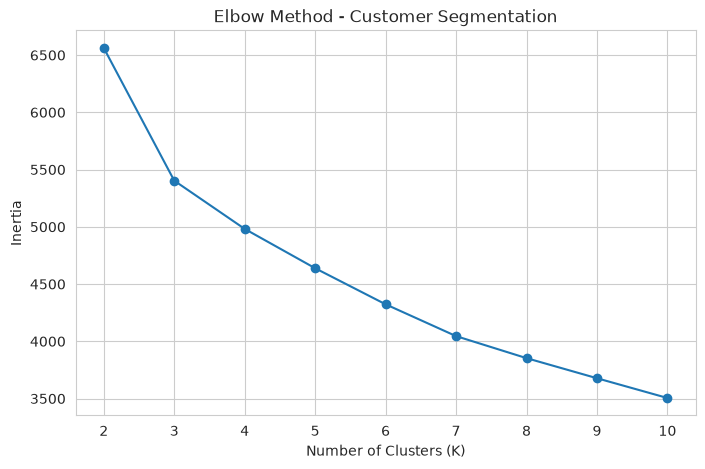

In [21]:
inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_customer_scaled)

    inertia.append(
        kmeans.inertia_
    )

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Customer Segmentation")

plt.show()

In [23]:
silhouette_scores = []

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_customer_scaled
    )

    score = silhouette_score(
        X_customer_scaled,
        labels
    )

    silhouette_scores.append(score)

silhouette_results = pd.DataFrame({
    "k": list(K_range),
    "silhouette_score": silhouette_scores
})

silhouette_results

,k,silhouette_score
0,2,0.232890
1,3,0.206364
2,4,0.196367
3,5,0.158187
4,6,0.161699
5,7,0.156632
6,8,0.151775
7,9,0.151047
8,10,0.149573


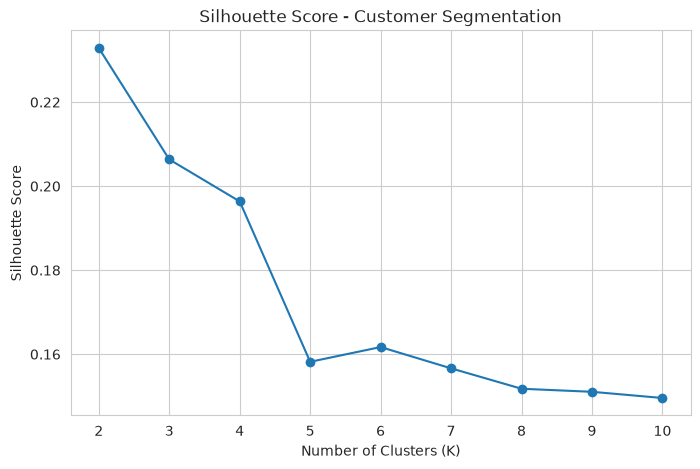

In [24]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_results["k"],
    silhouette_results["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Customer Segmentation")

plt.show()

In [25]:
# Choose number of clusters
K = 3

# Create final K-Means model
kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=10
)

# Train model and generate cluster labels
customer_clusters = kmeans.fit_predict(
    X_customer_scaled
)

print("K-Means model trained successfully.")
print("Number of clusters:", K)

K-Means model trained successfully.
Number of clusters: 3


In [26]:
customer_features["cluster"] = customer_clusters

customer_features.head()

,customer_id,total_orders,average_order_value,total_spending,weekend_orders,late_night_orders,active_months_x,ordering_frequency,active_months_y,average_rating_given,cluster
0,CUST_0001,5,157.950000,789.75,2,2,5.466667,0.914634,5.466667,3.600000,0
1,CUST_0002,3,125.346667,376.04,1,1,2.300000,1.304348,2.300000,3.666667,2
2,CUST_0003,3,194.970000,584.91,0,1,1.366667,2.195122,1.366667,3.333333,2
3,CUST_0004,3,280.410000,841.23,1,1,5.033333,0.596026,5.033333,4.000000,0
4,CUST_0005,2,148.730000,297.46,0,2,4.466667,0.447761,4.466667,3.000000,0


In [27]:
cluster_counts = customer_features["cluster"].value_counts().sort_index()

print(cluster_counts)

cluster
0    413
1    314
2    265
Name: count, dtype: int64


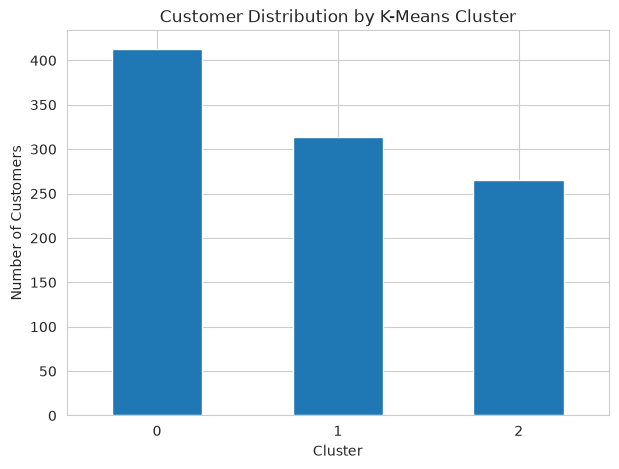

In [28]:
plt.figure(figsize=(7, 5))

cluster_counts.plot(
    kind="bar"
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Customer Distribution by K-Means Cluster")

plt.xticks(rotation=0)

plt.show()

In [29]:
cluster_profile = customer_features.groupby(
    "cluster"
).agg(
    total_customers=("customer_id", "count"),
    avg_total_orders=("total_orders", "mean"),
    avg_order_value=("average_order_value", "mean"),
    avg_total_spending=("total_spending", "mean"),
    avg_ordering_frequency=("ordering_frequency", "mean"),
    avg_rating_given=("average_rating_given", "mean"),
    avg_weekend_orders=("weekend_orders", "mean"),
    avg_late_night_orders=("late_night_orders", "mean")
).round(2)

cluster_profile

,total_customers,avg_total_orders,avg_order_value,avg_total_spending,avg_ordering_frequency,avg_rating_given,avg_weekend_orders,avg_late_night_orders
cluster,,,,,,,,
0,413,4.26,212.47,893.08,1.00,3.16,1.20,1.31
1,314,7.62,224.97,1693.74,1.72,3.21,2.35,2.81
2,265,3.20,211.71,677.59,1.77,3.23,0.86,1.01


In [30]:
cluster_names = {
    0: "Regular Moderate-Value Customers",
    1: "Premium Frequent Diners",
    2: "Occasional Low-Spend Customers"
}

customer_features["cluster_name"] = (
    customer_features["cluster"]
    .map(cluster_names)
)

customer_features.head()

,customer_id,total_orders,average_order_value,total_spending,weekend_orders,late_night_orders,active_months_x,ordering_frequency,active_months_y,average_rating_given,cluster,cluster_name
0,CUST_0001,5,157.950000,789.75,2,2,5.466667,0.914634,5.466667,3.600000,0,Regular Moderate-Value Customers
1,CUST_0002,3,125.346667,376.04,1,1,2.300000,1.304348,2.300000,3.666667,2,Occasional Low-Spend Customers
2,CUST_0003,3,194.970000,584.91,0,1,1.366667,2.195122,1.366667,3.333333,2,Occasional Low-Spend Customers
3,CUST_0004,3,280.410000,841.23,1,1,5.033333,0.596026,5.033333,4.000000,0,Regular Moderate-Value Customers
4,CUST_0005,2,148.730000,297.46,0,2,4.466667,0.447761,4.466667,3.000000,0,Regular Moderate-Value Customers


In [31]:
customer_features[
    [
        "customer_id",
        "cluster",
        "cluster_name"
    ]
].head(10)

,customer_id,cluster,cluster_name
0,CUST_0001,0,Regular Moderate-Value Customers
1,CUST_0002,2,Occasional Low-Spend Customers
2,CUST_0003,2,Occasional Low-Spend Customers
3,CUST_0004,0,Regular Moderate-Value Customers
4,CUST_0005,0,Regular Moderate-Value Customers
5,CUST_0006,0,Regular Moderate-Value Customers
6,CUST_0007,1,Premium Frequent Diners
7,CUST_0008,1,Premium Frequent Diners
8,CUST_0009,0,Regular Moderate-Value Customers
9,CUST_0010,0,Regular Moderate-Value Customers


In [32]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_customer_pca = pca.fit_transform(
    X_customer_scaled
)

print("Original number of features:", X_customer_scaled.shape[1])
print("PCA components:", X_customer_pca.shape[1])

Original number of features: 9
PCA components: 2


In [33]:
explained_variance = pca.explained_variance_ratio_

print("PC1:", round(explained_variance[0], 3))
print("PC2:", round(explained_variance[1], 3))
print(
    "Total:",
    round(explained_variance.sum(), 3)
)

PC1: 0.408
PC2: 0.215
Total: 0.622


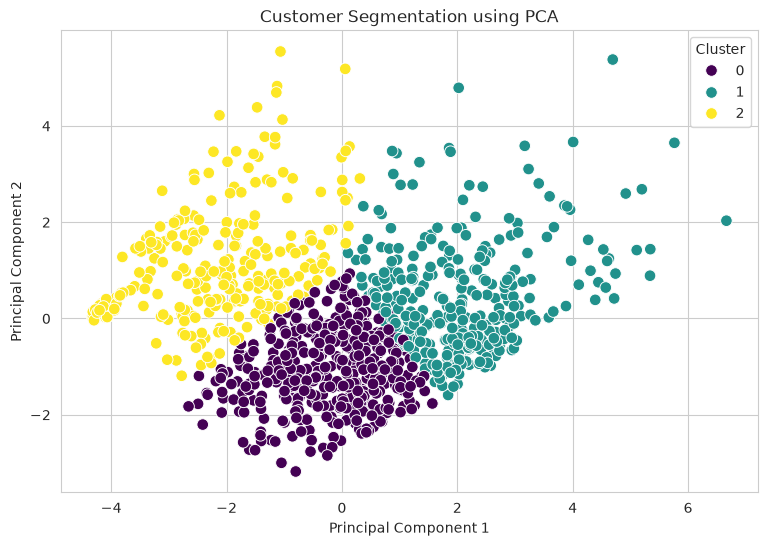

In [34]:
pca_df = pd.DataFrame({
    "PC1": X_customer_pca[:, 0],
    "PC2": X_customer_pca[:, 1],
    "cluster": customer_features["cluster"]
})

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.show()

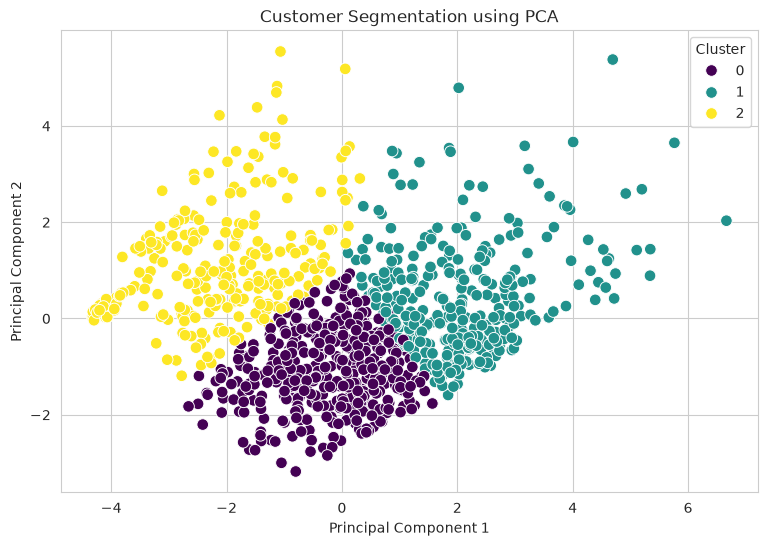

PCA plot saved successfully.


In [36]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")

plt.savefig(
    "../outputs/plots/customer_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("PCA plot saved successfully.")

In [37]:
import joblib

In [38]:
joblib.dump(
    kmeans,
    "../outputs/models/customer_kmeans.pkl"
)

print("K-Means model saved successfully.")

K-Means model saved successfully.


In [39]:
joblib.dump(
    scaler,
    "../outputs/models/customer_scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


In [40]:
from sklearn.neighbors import NearestNeighbors

print("NearestNeighbors imported successfully.")

NearestNeighbors imported successfully.


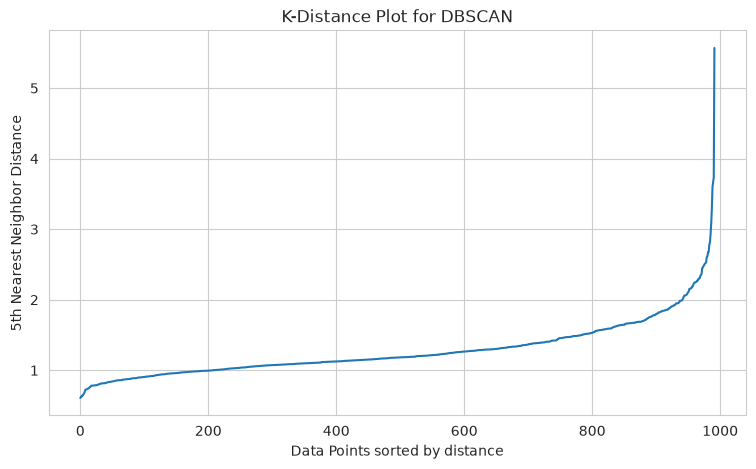

In [41]:
min_samples = 5

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(X_customer_scaled)

distances, indices = neighbors.kneighbors(
    X_customer_scaled
)

# Distance to the 5th nearest neighbor
k_distances = np.sort(
    distances[:, -1]
)

plt.figure(figsize=(9, 5))

plt.plot(k_distances)

plt.xlabel("Data Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("K-Distance Plot for DBSCAN")

plt.show()

In [43]:
eps_values = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6]

dbscan_results = []

for eps in eps_values:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(
        X_customer_scaled
    )

    n_clusters = len(
        set(labels)
    ) - (1 if -1 in labels else 0)

    n_noise = np.sum(
        labels == -1
    )

    # Calculate silhouette only if there are at least 2 clusters
    if n_clusters >= 2:
        non_noise_mask = labels != -1

        if len(set(labels[non_noise_mask])) >= 2:
            silhouette = silhouette_score(
                X_customer_scaled[non_noise_mask],
                labels[non_noise_mask]
            )
        else:
            silhouette = np.nan
    else:
        silhouette = np.nan

    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "noise_percentage": round(
            n_noise / len(labels) * 100,
            2
        ),
        "silhouette_score": silhouette
    })

dbscan_results = pd.DataFrame(
    dbscan_results
)

dbscan_results

,eps,clusters,noise_points,noise_percentage,silhouette_score
0,0.6,0,992,100.00,NaN
1,0.8,7,929,93.65,0.450813
2,1.0,8,589,59.38,-0.063966
3,1.2,4,282,28.43,0.056338
4,1.4,4,150,15.12,0.046013
5,1.6,3,75,7.56,0.217311


In [44]:
# Final DBSCAN parameters
dbscan = DBSCAN(
    eps=1.6,
    min_samples=5
)

# Fit DBSCAN
dbscan_labels = dbscan.fit_predict(
    X_customer_scaled
)

print("DBSCAN model trained successfully.")
print("Number of labels:", len(set(dbscan_labels)))
print("Noise points:", np.sum(dbscan_labels == -1))

DBSCAN model trained successfully.
Number of labels: 4
Noise points: 75


In [45]:
customer_features["dbscan_cluster"] = dbscan_labels

customer_features[
    [
        "customer_id",
        "cluster",
        "cluster_name",
        "dbscan_cluster"
    ]
].head(10)

,customer_id,cluster,cluster_name,dbscan_cluster
0,CUST_0001,0,Regular Moderate-Value Customers,0
1,CUST_0002,2,Occasional Low-Spend Customers,0
2,CUST_0003,2,Occasional Low-Spend Customers,0
3,CUST_0004,0,Regular Moderate-Value Customers,0
4,CUST_0005,0,Regular Moderate-Value Customers,0
5,CUST_0006,0,Regular Moderate-Value Customers,0
6,CUST_0007,1,Premium Frequent Diners,0
7,CUST_0008,1,Premium Frequent Diners,0
8,CUST_0009,0,Regular Moderate-Value Customers,0
9,CUST_0010,0,Regular Moderate-Value Customers,-1


In [46]:
dbscan_distribution = (
    customer_features["dbscan_cluster"]
    .value_counts()
    .sort_index()
)

print(dbscan_distribution)

dbscan_cluster
-1     75
 0    901
 1      7
 2      9
Name: count, dtype: int64


In [47]:
non_noise_mask = (
    dbscan_labels != -1
)

dbscan_silhouette = silhouette_score(
    X_customer_scaled[non_noise_mask],
    dbscan_labels[non_noise_mask]
)

print(
    "DBSCAN Silhouette Score:",
    round(dbscan_silhouette, 4)
)

DBSCAN Silhouette Score: 0.2173


In [48]:
X_customer_pca

array([[ 0.81889649, -1.75228672],
       [-2.30166419,  0.12942617],
       [-2.72107774,  1.7351427 ],
       ...,
       [-2.22631251,  3.46510202],
       [ 2.89765712,  2.08216732],
       [-4.20176078,  0.17194478]], shape=(992, 2))

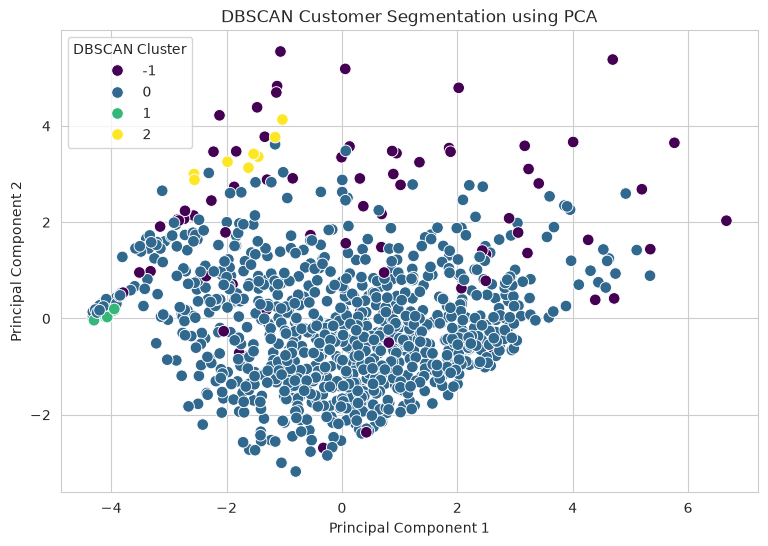

In [49]:
dbscan_pca_df = pd.DataFrame({
    "PC1": X_customer_pca[:, 0],
    "PC2": X_customer_pca[:, 1],
    "dbscan_cluster": dbscan_labels
})

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=dbscan_pca_df,
    x="PC1",
    y="PC2",
    hue="dbscan_cluster",
    palette="viridis",
    s=70
)

plt.title("DBSCAN Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="DBSCAN Cluster")

plt.show()

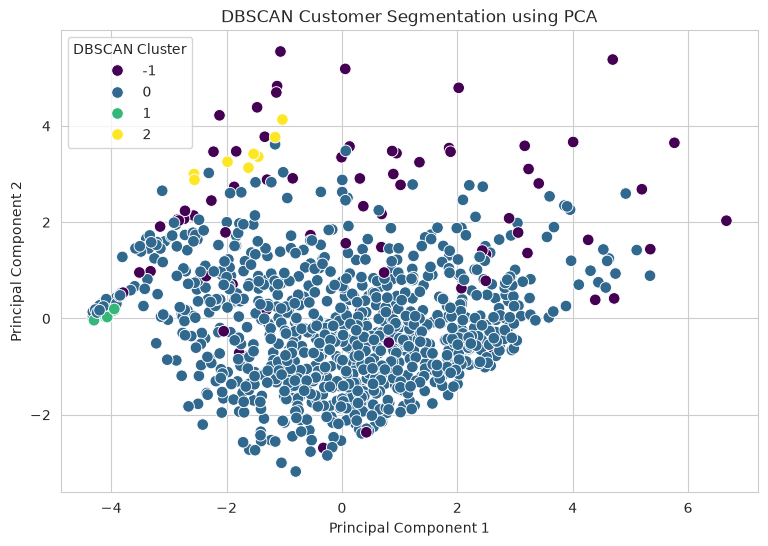

DBSCAN PCA plot saved successfully.


In [51]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=dbscan_pca_df,
    x="PC1",
    y="PC2",
    hue="dbscan_cluster",
    palette="viridis",
    s=70
)

plt.title("DBSCAN Customer Segmentation using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="DBSCAN Cluster")

plt.savefig(
    "../outputs/plots/customer_dbscan_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("DBSCAN PCA plot saved successfully.")

In [52]:
joblib.dump(
    dbscan,
    "../outputs/models/customer_dbscan.pkl"
)

print("DBSCAN model saved successfully.")

DBSCAN model saved successfully.


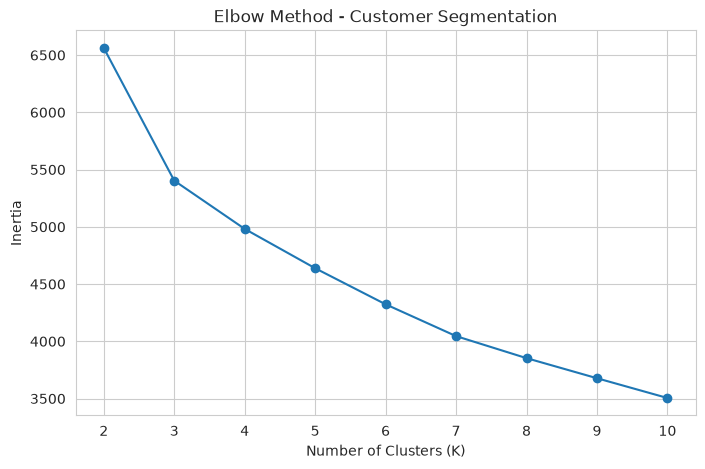

Elbow plot saved successfully.


In [53]:
plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Customer Segmentation")

plt.savefig(
    "../outputs/plots/customer_elbow.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Elbow plot saved successfully.")

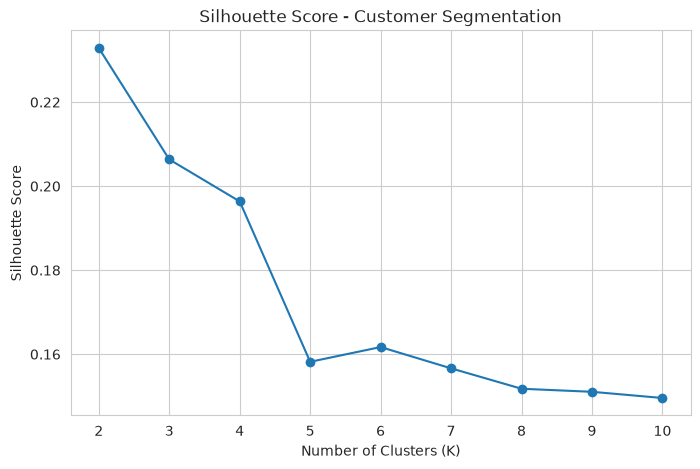

Silhouette plot saved successfully.


In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_results["k"],
    silhouette_results["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Customer Segmentation")

plt.savefig(
    "../outputs/plots/customer_silhouette.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Silhouette plot saved successfully.")

In [55]:
customer_model_comparison = pd.DataFrame({
    "Model": [
        "K-Means",
        "DBSCAN"
    ],
    "Number_of_clusters": [
        3,
        3
    ],
    "Silhouette_Score": [
        silhouette_score(
            X_customer_scaled,
            customer_clusters
        ),
        dbscan_silhouette
    ],
    "Noise_percentage": [
        0,
        round(
            np.sum(dbscan_labels == -1)
            / len(dbscan_labels) * 100,
            2
        )
    ]
})

customer_model_comparison

,Model,Number_of_clusters,Silhouette_Score,Noise_percentage
0,K-Means,3,0.206364,0.00
1,DBSCAN,3,0.217311,7.56


In [56]:
customer_features.to_csv(
    "../data/processed/customer_segmentation_features.csv",
    index=False
)

print("Customer feature dataset saved successfully.")

Customer feature dataset saved successfully.
